In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import truncnorm
from scipy.optimize import minimize
from scipy.stats import norm
import xlwings as xw
import statsmodels.api as sm
import math

             Preco
Data              
1996-09-02  123.09
1996-09-03  119.68
1996-09-04  119.39
1996-09-05  118.42
1996-09-06  118.09
              Preco
Data               
2025-10-13  2219.96
2025-10-14  2301.24
2025-10-15  2314.21
2025-10-16  2269.67
2025-10-17  2262.88


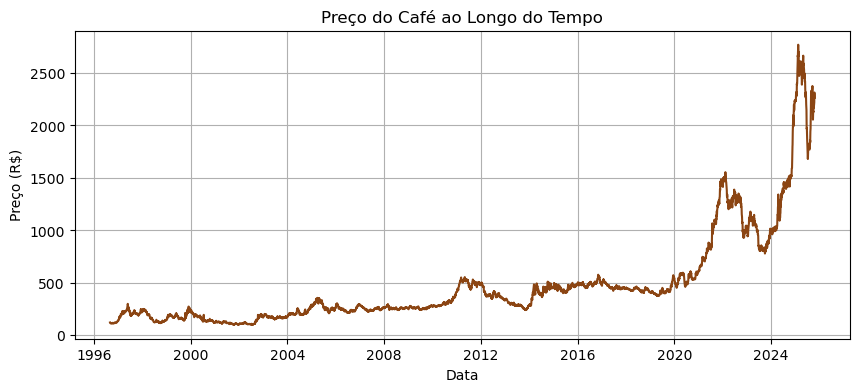

=== Estatísticas Descritivas ===
count    7255.000000
mean      474.544509
std       450.893020
min       101.480000
25%       218.190000
50%       310.620000
75%       489.195000
max      2769.450000

=== Estatísticas dos Retornos Logarítmicos ===
count    7254.000000
mean        0.000401
std         0.018661
min        -0.162006
25%        -0.008008
50%         0.000357
75%         0.008958
max         0.256636


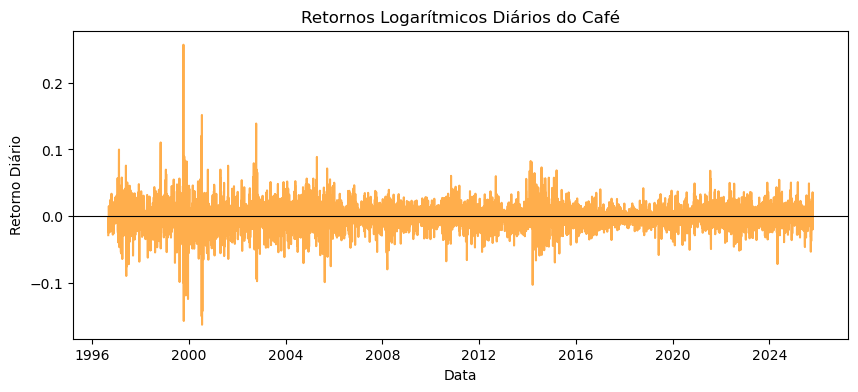

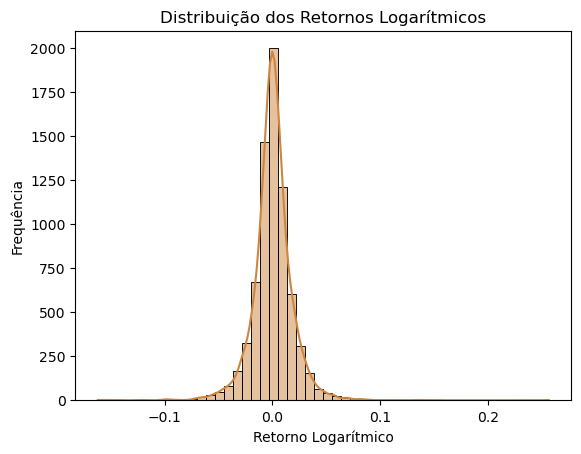

=== Medidas de Forma dos Retornos ===
Curtose (Kurtosis): 11.6924


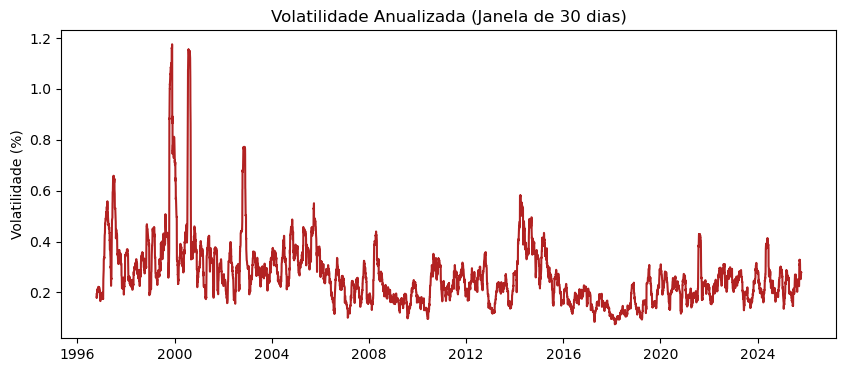


Resumo dos Retornos Logarítmicos:
                       0
Média           0.000401
Desvio-Padrão   0.018661
Assimetria      0.143039
Curtose        11.692431
Min            -0.162006
Max             0.256636


In [6]:
# Ler o arquivo Excel
df = pd.read_excel('Preços café.xls')
df.columns = ['Data', 'Preco']
df['Data'] = pd.to_datetime(df['Data'], format='%d/%m/%Y')
df = df.sort_values('Data').set_index('Data')

# Visualizar início e fim da série
print(df.head())
print(df.tail())

# Plotar a série
plt.figure(figsize=(10,4))
plt.plot(df['Preco'], color='saddlebrown')
plt.title('Preço do Café ao Longo do Tempo')
plt.ylabel('Preço (R$)')
plt.xlabel('Data')
plt.grid(True)
plt.show()

# Estatísticas básicas
print("=== Estatísticas Descritivas ===")
print(df['Preco'].describe().to_string())

# Retornos logarítmicos
df['Retorno_Log'] = np.log(df['Preco'] / df['Preco'].shift(1))
print("\n=== Estatísticas dos Retornos Logarítmicos ===")
print(df['Retorno_Log'].describe().to_string())

# Plot dos retornos
plt.figure(figsize=(10,4))
plt.plot(df['Retorno_Log'], color='darkorange', alpha=0.7)
plt.title('Retornos Logarítmicos Diários do Café')
plt.ylabel('Retorno Diário')
plt.xlabel('Data')
plt.axhline(0, color='black', lw=0.8)
plt.show()

sns.histplot(df['Retorno_Log'].dropna(), bins=50, kde=True, color='peru')
plt.title('Distribuição dos Retornos Logarítmicos')
plt.xlabel('Retorno Logarítmico')
plt.ylabel('Frequência')
plt.show()

print("=== Medidas de Forma dos Retornos ===")
print(f"Curtose (Kurtosis): {kurtosis(df['Retorno_Log'].dropna(), fisher=True):.4f}")

# Volatilidade móvel (desvio-padrão de 30 dias)
df['Volatilidade_30d'] = df['Retorno_Log'].rolling(window=30).std() * np.sqrt(252)  # anualizada
plt.figure(figsize=(10,4))
plt.plot(df['Volatilidade_30d'], color='firebrick')
plt.title('Volatilidade Anualizada (Janela de 30 dias)')
plt.ylabel('Volatilidade (%)')
plt.show()

summary = pd.DataFrame({
    'Média': [df['Retorno_Log'].mean()],
    'Desvio-Padrão': [df['Retorno_Log'].std()],
    'Assimetria': [skew(df['Retorno_Log'].dropna())],
    'Curtose': [kurtosis(df['Retorno_Log'].dropna(), fisher=True)],
    'Min': [df['Retorno_Log'].min()],
    'Max': [df['Retorno_Log'].max()]
})
print("\nResumo dos Retornos Logarítmicos:")
print(summary.T)

In [11]:
# ==============================================================
# 2. FUNÇÃO DE VEROSSIMILHANÇA (LOG-LIKELIHOOD) DE MERTON
# ==============================================================

retornos = df['Retorno_Log'].dropna().values

def merton_log_likelihood(params, data):
    mu, sigma, lamb, mu_j, sigma_j = params
    if sigma <= 0 or lamb < 0 or sigma_j <= 0:
        return 1e10
    
    dt = 1 
    likelihood = 0
    for k in range(10):
        p_k = (np.exp(-lamb * dt) * (lamb * dt)**k) / math.factorial(k)
        
        mu_total = (mu - 0.5 * sigma**2) * dt + k * mu_j
        var_total = (sigma**2 * dt) + k * (sigma_j**2)
        
        likelihood += p_k * norm.pdf(data, loc=mu_total, scale=np.sqrt(var_total))
    
    return -np.sum(np.log(likelihood))
    
# ==============================================================
# 3. ESTIMAÇÃO VIA MLE (MÉTODO DO ARTIGO)
# ==============================================================
# Palpites iniciais (usando seus cálculos anteriores como base)
initial_guess = [retornos.mean(), retornos.std(), 0.05, 0.0, retornos.std()*2]

# Otimização numérica
result = minimize(merton_log_likelihood, initial_guess, args=(retornos,),
                  method='L-BFGS-B', 
                  bounds=[(None, None), (1e-6, None), (1e-6, 1), (None, None), (1e-6, None)])

mu_mle, sigma_mle, lamb_mle, muj_mle, sigmaj_mle = result.x

# ==============================================================
# 4. RESULTADOS E COMPARAÇÃO
# ==============================================================
print("---- Parâmetros Estimados via MLE (Berhane et al. 2019) ----")
print(f"μ (drift): {mu_mle:.6f}")
print(f"σ (volatilidade contínua): {sigma_mle:.6f}")
print(f"λ (intensidade de saltos): {lamb_mle:.6f}")
print(f"μ_j (média do salto): {muj_mle:.6f}")
print(f"σ_j (desvio do salto): {sigmaj_mle:.6f}")

---- Parâmetros Estimados via MLE (Berhane et al. 2019) ----
μ (drift): 0.000347
σ (volatilidade contínua): 0.008406
λ (intensidade de saltos): 0.640597
μ_j (média do salto): 0.000139
σ_j (desvio do salto): 0.019953


--- Validação de Consistência (6 anos) ---
Preço Médio Simulado: R$ 5475.30
Esperança Teórica:    R$ 5484.36
Diferença Relativa:   0.1652%
------------------------------------------


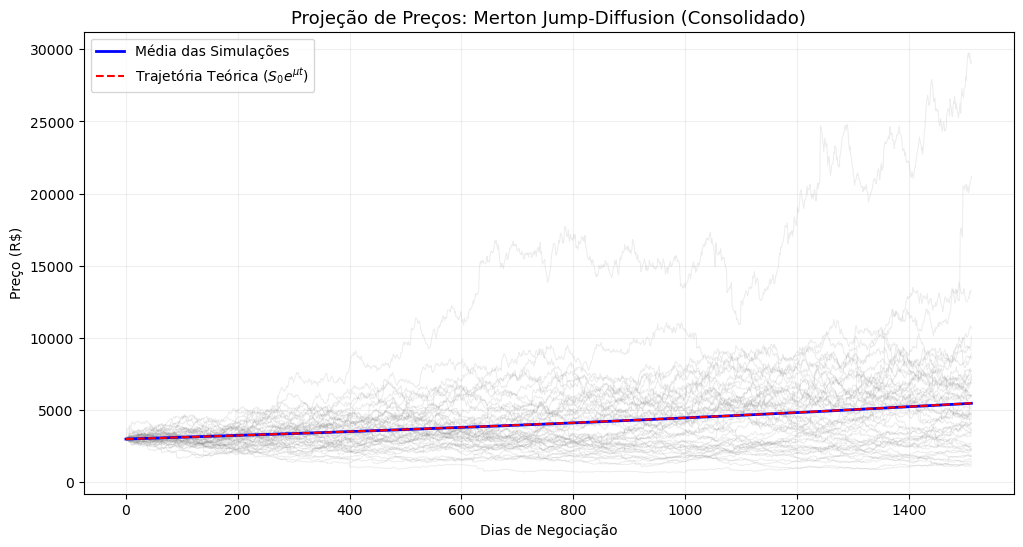

In [14]:
# ==============================================================
# 1. PARÂMETROS ESTIMADOS (BASE DIÁRIA)
# ==============================================================
mu_mle    = 0.000347    # Drift diário
sigma_mle = 0.008406    # Volatilidade contínua diária
lamb_mle  = 0.640597    # Intensidade diária (média de saltos por dia)
muj_mle   = 0.000139    # Média do log-salto (magnitude)
sigmaj_mle = 0.019953   # Desvio padrão do log-salto

# ==============================================================
# 2. AJUSTES MATEMÁTICOS CRÍTICOS (MERTON / BERHANE)
# ==============================================================
# k: Esperança do salto no preço (E[exp(J)] - 1)
# Essencial para que o drift mu_star compense a convexidade do salto
k = np.exp(mu_j + 0.5 * sigma_j**2) - 1

# mu_star: Drift compensado (removendo a parte que o Poisson reintroduz)
mu_star = mu_total - (lambda_j * k)

# ==============================================================
# 3. MONTE CARLO VETORIZADO
# ==============================================================
# A. Componente Contínuo (Browniano) com ajuste de convexidade de Itô
Z = np.random.normal(0, 1, (simulacoes, total_periodos))
retorno_continuo = (mu_star - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

# B. Componente de Saltos (Poisson Composto)
N = np.random.poisson(lambda_j * dt, (simulacoes, total_periodos))
# Propriedade: Soma de N normais ~ N(N*mu, sqrt(N)*sigma)
Y = np.random.normal(N * mu_j, np.sqrt(N) * sigma_j)
Y[N == 0] = 0  # Garante que onde não houve salto, o impacto é nulo

# C. Evolução dos Preços (Acúmulo Logarítmico)
log_returns = retorno_continuo + Y
caminhos_acumulados = np.exp(np.cumsum(log_returns, axis=1))
resultados = preco_inicial * caminhos_acumulados

# Adiciona o preço inicial na primeira coluna (tempo 0)
resultados = np.insert(resultados, 0, preco_inicial, axis=1)

# ==============================================================
# 4. VALIDAÇÃO E ESTATÍSTICAS
# ==============================================================
valores_finais = resultados[:, -1]
esperanca_teorica = preco_inicial * np.exp(mu_total * anos)

print(f"--- Validação de Consistência (6 anos) ---")
print(f"Preço Médio Simulado: R$ {np.mean(valores_finais):.2f}")
print(f"Esperança Teórica:    R$ {esperanca_teorica:.2f}")
print(f"Diferença Relativa:   {abs(np.mean(valores_finais)/esperanca_teorica - 1)*100:.4f}%")
print("-" * 42)

# ==============================================================
# 5. VISUALIZAÇÃO
# ==============================================================
plt.figure(figsize=(12, 6))

# Amostra de caminhos individuais
plt.plot(resultados[:50, :].T, color='gray', alpha=0.15, linewidth=0.7)

# Média das simulações (deve seguir a teoria)
plt.plot(np.mean(resultados, axis=0), color='blue', linewidth=2, label='Média das Simulações')

# Curva teórica esperada
tempo_eixo = np.linspace(0, anos, total_periodos + 1)
plt.plot(preco_inicial * np.exp(mu_total * tempo_eixo), 
         color='red', linestyle='--', linewidth=1.5, label='Trajetória Teórica ($S_0 e^{\mu t}$)')

plt.title("Projeção de Preços: Merton Jump-Diffusion (Consolidado)", fontsize=13)
plt.xlabel("Dias de Negociação")
plt.ylabel("Preço (R$)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

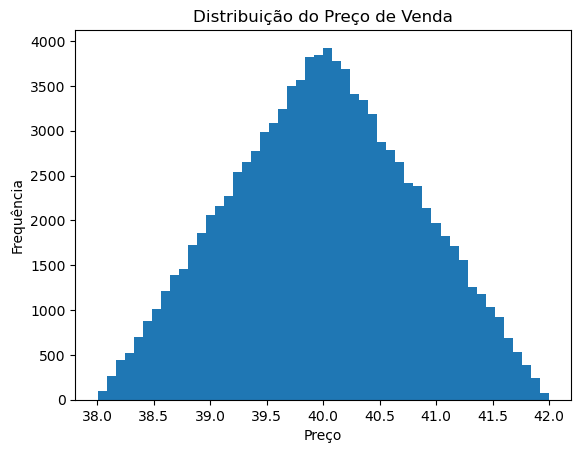

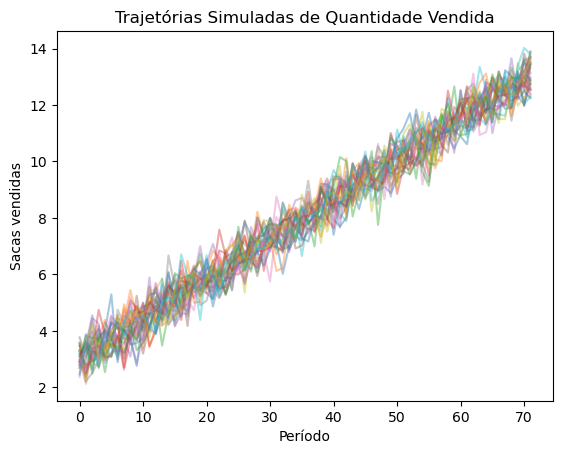

In [8]:
# Preço café verde
preco_cafe_verde = valores_finais

# Preço vendas
preco_venda = np.random.triangular(
    left=38,
    mode=40,
    right=42,
    size=simulacoes
)

# -----------------------------
# QUANTIDADE VENDIDA (SACAS)
# -----------------------------

simulacoes = n_sim_real
periodos = n_meses

media_inicial = 3
media_final = 13
desvio = 0.5

media_periodo = np.linspace(media_inicial, media_final, periodos)

quantidade = np.zeros((simulacoes, periodos))

for t in range(periodos):

    a = (0 - media_periodo[t]) / desvio
    b = np.inf

    quantidade[:, t] = truncnorm.rvs(
        a,
        b,
        loc=media_periodo[t],
        scale=desvio,
        size=simulacoes
    )
    
# Histograma preço de venda
plt.figure()
plt.hist(preco_venda, bins=50)
plt.title("Distribuição do Preço de Venda")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

# Trajetória das vendas simuladas
plt.figure()

for i in range(30):
    plt.plot(quantidade[i], alpha=0.4)

plt.title("Trajetórias Simuladas de Quantidade Vendida")
plt.xlabel("Período")
plt.ylabel("Sacas vendidas")

plt.show()

In [ ]:
# -----------------------------
# CONFIGURAÇÕES
# -----------------------------

dias_por_mes = 21
arquivo_excel = "Modelagem Cafés Especiais Teste.xlsx"
aba_excel = "Distribuições"
celula_vpl = "C39"

n_sim = 300

# -----------------------------
# CONECTAR AO EXCEL
# -----------------------------

wb = xw.Book(arquivo_excel)
sheet = wb.sheets[aba_excel]

app = wb.app
app.screen_updating = False
app.calculation = 'manual'
app.display_alerts = False
app.enable_events = False

# -----------------------------
# PREPARAÇÃO
# -----------------------------

traj = resultados[:n_sim]

n_sim_real = traj.shape[0]
n_dias = traj.shape[1]

n_meses = n_dias // dias_por_mes

traj = traj[:, :n_meses * dias_por_mes]

precos_mensais_all = traj.reshape(
    n_sim_real,
    n_meses,
    dias_por_mes
).mean(axis=2)

preco_medio_sim = precos_mensais_all.mean(axis=1)

# -----------------------------
# PREÇO DE VENDA
# -----------------------------

preco_venda = np.random.triangular(
    38, 40, 42,
    size=(n_sim_real, n_meses)
)

# -----------------------------
# QUANTIDADE (SACAS)
# -----------------------------

media_inicial = 3
media_final = 13
desvio = 0.5

media_periodo = np.linspace(media_inicial, media_final, n_meses)

quantidade = np.zeros((n_sim_real, n_meses))

for t in range(n_meses):

    a = (0 - media_periodo[t]) / desvio
    b = np.inf

    quantidade[:, t] = truncnorm.rvs(
        a, b,
        loc=media_periodo[t],
        scale=desvio,
        size=n_sim_real
    )

# apenas 1 casa decimal
quantidade = np.round(quantidade, 1)

# -----------------------------
# MONTE CARLO
# -----------------------------

vpl_resultados = []

for i in range(n_sim_real):

    for m in range(n_meses):

        col = 4 + m*4  # D,H,L,P...

        sheet.cells(2, col).value = precos_mensais_all[i, m]
        sheet.cells(5, col).value = quantidade[i, m]
        sheet.cells(6, col).value = preco_venda[i, m]

    wb.app.calculate()

    vpl = sheet[celula_vpl].value

    if vpl is not None:
        vpl_resultados.append(float(vpl))

# -----------------------------
# FINALIZAR
# -----------------------------

app.calculation = 'automatic'
app.screen_updating = True
app.enable_events = True

vpl_resultados = np.array(vpl_resultados)

# -----------------------------
# RESULTADOS
# -----------------------------

print("VPL médio:", np.mean(vpl_resultados))
print("Probabilidade VPL negativo:", np.mean(vpl_resultados < 0))
print("Percentil 5%:", np.percentile(vpl_resultados,5))
print("Percentil 95%:", np.percentile(vpl_resultados,95))

tabela_vpl = pd.DataFrame({
    "Simulação": np.arange(1, len(vpl_resultados)+1),
    "VPL": vpl_resultados,
    "Preço médio do café": preco_medio_sim[:len(vpl_resultados)]
})

print("\n=== Alguns VPLs simulados ===")
print(tabela_vpl.head())


Preço crítico do café (VPL = 0): 3343.8686685092644

Resumo da regressão:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 8.710e+04
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:00:36   Log-Likelihood:                -11775.
No. Observations:                1000   AIC:                         2.355e+04
Df Residuals:                     998   BIC:                         2.356e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

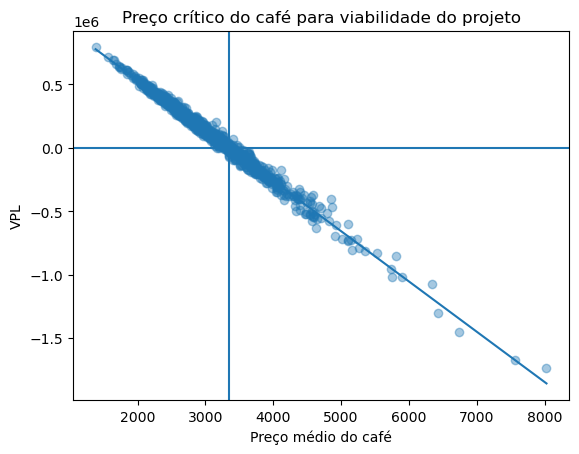

In [26]:
# variável explicativa
X = preco_medio_sim
X = sm.add_constant(X)

# regressão
modelo = sm.OLS(vpl_resultados, X).fit()

alpha = modelo.params[0]
beta = modelo.params[1]

preco_critico = -alpha / beta

print("\nPreço crítico do café (VPL = 0):", preco_critico)
print("\nResumo da regressão:")
print(modelo.summary())

np.float64(0.00040136170694099655)